# **Giai đoạn 1: Khám phá tập dữ liệu**

In [2]:
# Bước 1: Nhập thư viện
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# Bước 2: Tải tập dữ liệu
dataset = pd.read_csv('MalwareDataset.csv')

In [4]:
# Bước 3: Hiển thị năm dòng đầu tiên
print("5 dòng đầu tiên của tập dữ liệu:")
dataset.head()

5 dòng đầu tiên của tập dữ liệu:


,AddressOfEntryPoint,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,SizeOfStackReserve,NumberOfSections,ResourceSize,legitimate
0,10407,9,6,6,33088,262144,4,952,1
1,5354,9,6,6,33088,262144,4,952,1
2,58807,9,6,6,33088,262144,4,136490,1
3,25166,9,6,6,33088,262144,4,1940,1
4,70387,9,6,6,33088,262144,4,83098,1


In [5]:
# Bước 4: Hiểu rõ các cột và xác định mục tiêu
print("\nThông tin tập dữ liệu:")
dataset.info()  # Cung cấp tổng quan về các cột và kiểu dữ liệu
print("\nGiá trị duy nhất trong cột 'legitimate':")
dataset['legitimate'].value_counts()  # Xác nhận phân phối cột đích


Thông tin tập dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137444 entries, 0 to 137443
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype
---  ------                       --------------   -----
 0   AddressOfEntryPoint          137444 non-null  int64
 1   MajorLinkerVersion           137444 non-null  int64
 2   MajorImageVersion            137444 non-null  int64
 3   MajorOperatingSystemVersion  137444 non-null  int64
 4   DllCharacteristics           137444 non-null  int64
 5   SizeOfStackReserve           137444 non-null  int64
 6   NumberOfSections             137444 non-null  int64
 7   ResourceSize                 137444 non-null  int64
 8   legitimate                   137444 non-null  int64
dtypes: int64(9)
memory usage: 9.4 MB

Giá trị duy nhất trong cột 'legitimate':


legitimate
0    96526
1    40918
Name: count, dtype: int64

In [6]:
# Bước 5: Thống kê mô tả
print("\nThống kê mô tả:")
dataset.describe()


Thống kê mô tả:


,AddressOfEntryPoint,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,SizeOfStackReserve,NumberOfSections,ResourceSize,legitimate
count,1.374440e+05,137444.000000,137444.000000,137444.000000,137444.000000,1.374440e+05,137444.000000,1.374440e+05,137444.000000
mean,1.722186e+05,8.620784,68.731876,5.098738,22301.043436,9.306841e+05,4.997119,2.474766e+05,0.297707
std,3.438014e+06,4.095635,1185.709873,99.437584,15444.753219,5.553175e+05,1.917237,2.129516e+07,0.457252
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000e+00,0.000000
25%,1.272100e+04,8.000000,0.000000,4.000000,320.000000,1.048576e+06,4.000000,2.216000e+03,0.000000
50%,5.300800e+04,9.000000,0.000000,5.000000,33088.000000,1.048576e+06,5.000000,9.640000e+03,0.000000
75%,6.157800e+04,10.000000,6.000000,5.000000,33088.000000,1.048576e+06,5.000000,2.376250e+04,1.000000
max,1.074484e+09,255.000000,28619.000000,36868.000000,49504.000000,3.355443e+07,40.000000,4.294903e+09,1.000000


In [7]:
# Bước 6: Kiểm tra các giá trị bị thiếu
print("\nGiá trị bị thiếu trong mỗi cột:")
dataset.isnull().sum()


Giá trị bị thiếu trong mỗi cột:


AddressOfEntryPoint            0
MajorLinkerVersion             0
MajorImageVersion              0
MajorOperatingSystemVersion    0
DllCharacteristics             0
SizeOfStackReserve             0
NumberOfSections               0
ResourceSize                   0
legitimate                     0
dtype: int64

**1) Có bao nhiêu tệp hợp pháp và độc hại trong tập dữ liệu?**

* **Tệp hợp pháp:** 40.918
* **Tệp độc hại:** 96.526

**2) Các đặc trưng nào dường như phân biệt tệp hợp pháp khỏi malware?**

Bằng cách phân tích thống kê mô tả:

* **ResourceSize:** Giá trị trung bình của ResourceSize là 247.476 nhưng biến động rộng. Malware có thể có các giá trị cực trị hơn trong đặc trưng này so với tệp hợp pháp.
* **DllCharacteristics:** Tệp hợp pháp có thể có các đặc điểm cụ thể và nhất quán hơn, trong khi malware có thể thể hiện nhiều biến động hơn.
* **MajorImageVersion và MajorOperatingSystemVersion:** Nhiều tệp có giá trị 0 cho các đặc trưng này, có thể gợi ý siêu dữ liệu mặc định hoặc bị thiếu có thể phổ biến hơn trong malware.
* **NumberOfSections:** Tệp malware có thể có các giá trị bất thường ở đây so với các tệp hợp pháp.
* **AddressOfEntryPoint:** Các giá trị phạm vi và trung bình khá lớn, có thể phân biệt các tệp lành tính khỏi malware nếu phân phối các điểm vào rõ ràng khác nhau.

# **Giai đoạn 2: Chuẩn bị dữ liệu**

In [8]:
# Bước 1: Chia tập dữ liệu thành các đặc trưng (X) và mục tiêu (y)
X = dataset.drop(columns=['legitimate'])  # Các đặc trưng
y = dataset['legitimate']  # Mục tiêu

In [9]:
# Bước 2: Chia dữ liệu thành tập huấn luyện (80%) và tập kiểm tra (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
# Bước 3: Chuẩn hóa dữ liệu số
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Xác minh chuẩn hóa (trung bình ~0 và std ~1 cho dữ liệu huấn luyện)
print("\n5 dòng đầu tiên của dữ liệu huấn luyện đã chuẩn hóa:")
print(X_train_scaled[:5])

print("\nTrung bình các đặc trưng (tập huấn luyện):", X_train_scaled.mean(axis=0))
print("Độ lệch chuẩn các đặc trưng (tập huấn luyện):", X_train_scaled.std(axis=0))


5 dòng đầu tiên của dữ liệu huấn luyện đã chuẩn hóa:
[[-3.96330267e-02  5.60448982e-01 -5.77508438e-02 -1.47553480e-03
   6.98777598e-01  2.14132343e-01 -1.04240747e+00  1.32093737e-02]
 [-3.30981899e-02 -1.56001329e+00 -5.26696332e-02 -1.04705134e-02
   6.78063304e-01  2.14132343e-01  1.56744452e+00 -1.09426786e-02]
 [-5.05134816e-03 -1.46371776e-01 -5.77508438e-02 -1.04705134e-02
  -1.35608042e+00  2.14132343e-01 -1.04240747e+00 -1.09978509e-02]
 [-4.22390771e-02  3.24842062e-01 -5.26696332e-02 -1.47553480e-03
   7.65063341e-01  2.14132343e-01  5.23503720e-01 -7.97498777e-03]
 [-2.82469309e-02  5.60448982e-01 -5.77508438e-02 -1.47553480e-03
   6.94634739e-01  2.14132343e-01 -5.20437076e-01 -1.08729872e-02]]

Trung bình các đặc trưng (tập huấn luyện): [-2.58484920e-19  3.05012206e-17 -2.72701591e-17 -1.03393968e-18
 -1.00809119e-17 -1.99033389e-17  1.62587015e-16 -5.16969841e-19]
Độ lệch chuẩn các đặc trưng (tập huấn luyện): [1. 1. 1. 1. 1. 1. 1. 1.]


# **Giai đoạn 3: Tạo và huấn luyện mô hình**

# **Phần A: Các mô hình được giám sát**

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [13]:
# Bước 1: Huấn luyện mô hình Cây quyết định
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
# Dự đoán bằng mô hình Cây quyết định
dt_predictions = dt_model.predict(X_test_scaled)

In [15]:
# Đánh giá mô hình Cây quyết định
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f"Độ chính xác Cây quyết định: {dt_accuracy:.4f}")
print("\nBáo cáo phân loại Cây quyết định:")
print(classification_report(y_test, dt_predictions))

Độ chính xác Cây quyết định: 0.9879

Báo cáo phân loại Cây quyết định:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19305
           1       0.98      0.98      0.98      8184

    accuracy                           0.99     27489
   macro avg       0.98      0.99      0.99     27489
weighted avg       0.99      0.99      0.99     27489



In [16]:
# Bước 2: Huấn luyện mô hình Rừng ngẫu nhiên
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)  # Mặc định: 100 cây
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
# Dự đoán bằng mô hình Rừng ngẫu nhiên
rf_predictions = rf_model.predict(X_test_scaled)

In [18]:
# Đánh giá mô hình Rừng ngẫu nhiên
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"\nĐộ chính xác Rừng ngẫu nhiên: {rf_accuracy:.4f}")
print("\nBáo cáo phân loại Rừng ngẫu nhiên:")
print(classification_report(y_test, rf_predictions))


Độ chính xác Rừng ngẫu nhiên: 0.9919

Báo cáo phân loại Rừng ngẫu nhiên:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19305
           1       0.99      0.99      0.99      8184

    accuracy                           0.99     27489
   macro avg       0.99      0.99      0.99     27489
weighted avg       0.99      0.99      0.99     27489



**So sánh hiệu suất của Cây quyết định và Rừng ngẫu nhiên**

**Độ chính xác:**
* Cây quyết định: 98.79%
* Rừng ngẫu nhiên: 99.19%

**Nhận xét:**

Rừng ngẫu nhiên hoạt động tốt hơn Cây quyết định về độ chính xác. Điều này là do Rừng ngẫu nhiên sử dụng nhiều cây quyết định để giảm quá khớp và cải thiện khả năng tổng quát hóa.

**Báo cáo phân loại**

**Độ chính xác (Precision):**

* Cây quyết định (Lớp 0 - Malware): 0.99 | Lớp 1 - Hợp pháp: 0.98
* Rừng ngẫu nhiên (Lớp 0 - Malware): 0.99 | Lớp 1 - Hợp pháp: 0.99

**Nhận xét:**

Cả hai mô hình đều hoạt động tốt về độ chính xác, nhưng Rừng ngẫu nhiên hoạt động tốt hơn trong việc xác định các tệp hợp pháp (Lớp 1), với điểm độ chính xác cao hơn.

**Độ nhớ (Recall):**

* Cây quyết định (Lớp 0 - Malware): 0.99 | Lớp 1 - Hợp pháp: 0.98
* Rừng ngẫu nhiên (Lớp 0 - Malware): 0.99 | Lớp 1 - Hợp pháp: 0.99

**Nhận xét:**

Cả hai mô hình đều có độ nhớ rất cao cho cả hai lớp, nhưng Rừng ngẫu nhiên hoạt động tốt hơn Cây quyết định trong việc xác định các tệp hợp pháp (Lớp 1).

**Điểm F1 (F1-Score):**

* Cây quyết định (Lớp 0 - Malware): 0.99 | Lớp 1 - Hợp pháp: 0.98
* Rừng ngẫu nhiên (Lớp 0 - Malware): 0.99 | Lớp 1 - Hợp pháp: 0.99

**Nhận xét:**

Điểm F1 là trung bình điều hòa của độ chính xác và độ nhớ, và cả hai mô hình đều hoạt động tương tự về điểm F1. Tuy nhiên, Rừng ngẫu nhiên lại có lợi thế nhẹ cho các tệp hợp pháp (Lớp 1) do độ nhớ và độ chính xác được cải thiện.

**Ma trận nhầm lẫn:**

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


Ma trận nhầm lẫn Cây quyết định:
[[19120   185]
 [  147  8037]]


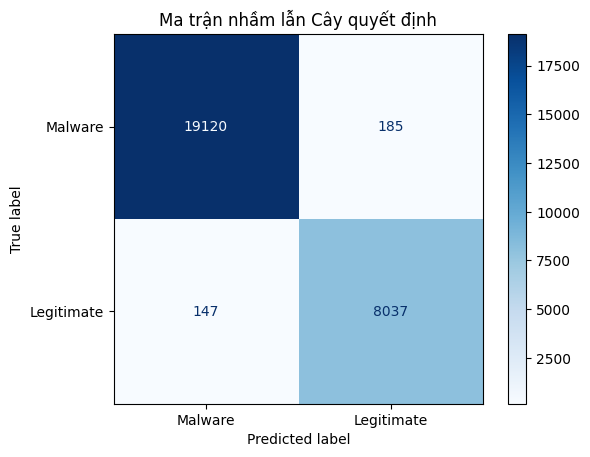

In [20]:
import matplotlib.pyplot as plt
# Ma trận nhầm lẫn Cây quyết định
dt_cm = confusion_matrix(y_test, dt_predictions)
print("\nMa trận nhầm lẫn Cây quyết định:")
print(dt_cm)
ConfusionMatrixDisplay(confusion_matrix=dt_cm, display_labels=['Malware', 'Legitimate']).plot(cmap='Blues')
plt.title("Ma trận nhầm lẫn Cây quyết định")
plt.show()


Ma trận nhầm lẫn Rừng ngẫu nhiên:
[[19184   121]
 [  102  8082]]


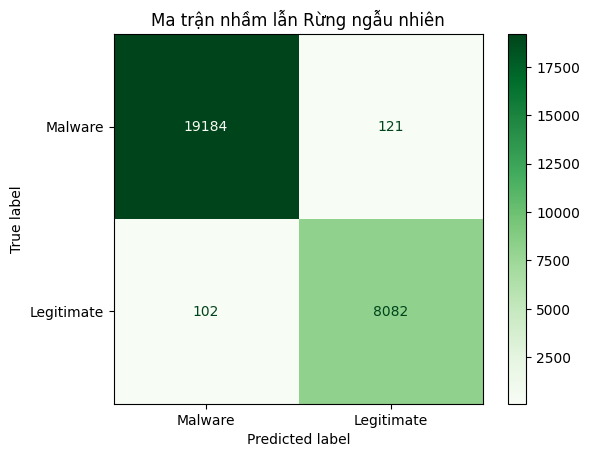

In [21]:
import matplotlib.pyplot as plt
# Ma trận nhầm lẫn Rừng ngẫu nhiên
rf_cm = confusion_matrix(y_test, rf_predictions)
print("\nMa trận nhầm lẫn Rừng ngẫu nhiên:")
print(rf_cm)
ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['Malware', 'Legitimate']).plot(cmap='Greens')
plt.title("Ma trận nhầm lẫn Rừng ngẫu nhiên")
plt.show()

**Âm thực (True Negatives):**
* Cây quyết định: 19120
* Rừng ngẫu nhiên: 19184

**Nhận xét:**

Rừng ngẫu nhiên hoạt động tốt hơn một chút trong việc phát hiện malware, vì nó có nhiều âm thực hơn, xác định chính xác nhiều tệp độc hại hơn.

**Dương giả (False Positives):**
* Cây quyết định: 185
* Rừng ngẫu nhiên: 121

**Nhận xét:**

Rừng ngẫu nhiên tạo ra ít cảnh báo giả hơn, có nghĩa là nó phân loại sai ít tệp malware là hợp pháp hơn Cây quyết định.

**Âm giả (False Negatives):**

* Cây quyết định: 147
* Rừng ngẫu nhiên: 102

**Nhận xét:**

Rừng ngẫu nhiên bỏ lỡ ít tệp hợp pháp hơn, dẫn đến tỷ lệ âm giả thấp hơn và cải thiện độ chính xác trong việc xác định tệp hợp pháp.

**Dương thực (True Positives):**

* Cây quyết định: 8037
* Rừng ngẫu nhiên: 8082

**Nhận xét:**

Rừng ngẫu nhiên xác định nhiều tệp hợp pháp là hợp pháp hơn, góp phần vào hiệu suất tổng thể tốt hơn của nó.

**So sánh toàn bộ**

Rừng ngẫu nhiên hoạt động tốt hơn Cây quyết định trong mọi chỉ số, mặc dù sự khác biệt là tối thiểu. Nó tốt hơn trong việc phát hiện tệp hợp pháp, với tỷ lệ dương giả và âm giả thấp hơn so với Cây quyết định.

# **Phần B: Mô hình không được giám sát**

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

In [23]:
# Bước 1: Triển khai KMeans với 2 cụm
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [24]:
# Bước 2: Lấy nhãn cụm dự đoán
cluster_labels = kmeans.labels_

In [25]:
# Bước 3: So sánh với nhãn thực tế (y_train)
cm = confusion_matrix(y_train, cluster_labels)
if cm[0, 1] > cm[1, 0]:
    cluster_labels = 1 - cluster_labels  # Đảo ngược nhãn cụm

In [26]:
# Bước 4: Tính chỉ số Adjusted Rand Index (ARI) để so sánh
ari_score = adjusted_rand_score(y_train, cluster_labels)
print(f"Chỉ số Rand điều chỉnh (ARI): {ari_score:.4f}")

Chỉ số Rand điều chỉnh (ARI): 0.4770


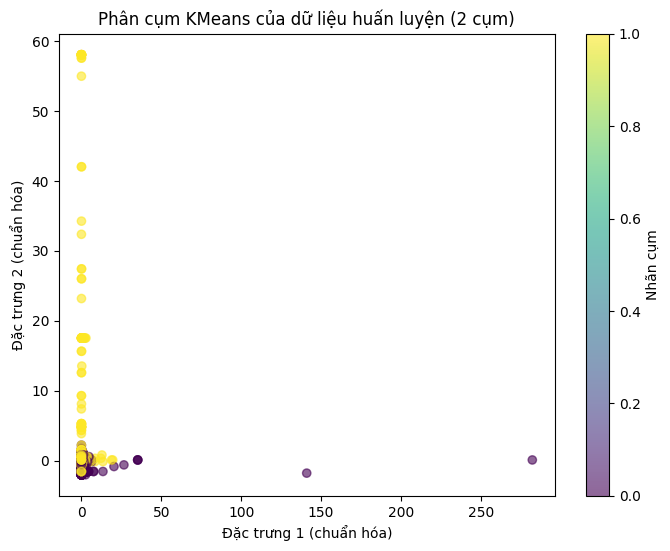

In [27]:
# Bước 5: Hình dung các cụm
plt.figure(figsize=(8, 6))

# Đồ thị phân tán của hai đặc trưng đầu tiên được tô màu theo nhãn cụm dự đoán
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.title("Phân cụm KMeans của dữ liệu huấn luyện (2 cụm)")
plt.xlabel("Đặc trưng 1 (chuẩn hóa)")
plt.ylabel("Đặc trưng 2 (chuẩn hóa)")
plt.colorbar(label='Nhãn cụm')
plt.show()

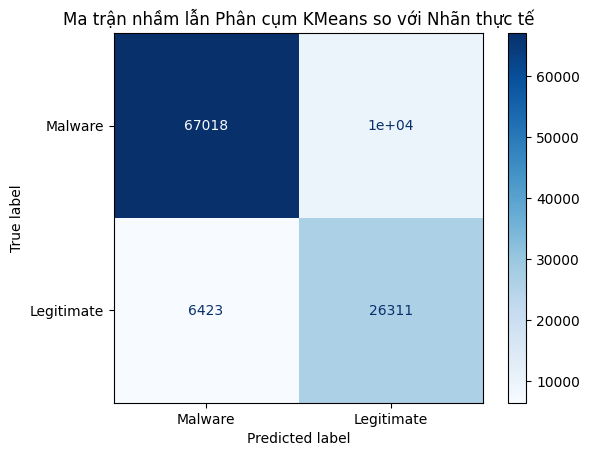

In [28]:
# Bước 6: Ma trận nhầm lẫn cho nhãn cụm so với nhãn thực tế
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malware', 'Legitimate']).plot(cmap='Blues')
plt.title("Ma trận nhầm lẫn Phân cụm KMeans so với Nhãn thực tế")
plt.show()

# **Phần C: Mô hình Học sâu**

In [29]:
# Kiểm tra import TensorFlow an toàn — nếu thất bại sẽ chuyển cờ tf_available = False
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.losses import BinaryCrossentropy
    from tensorflow.keras.metrics import AUC
    from tensorflow.keras.layers import Input
    tf_available = True
    print(f"TensorFlow phiên bản: {tf.__version__} — sẵn sàng sử dụng.")
except Exception as e:
    tf_available = False
    print("Không thể import TensorFlow:", str(e))
    print("Bỏ qua phần Học sâu. Để sửa, cài đặt các phiên bản tương thích, ví dụ:")
    print("  pip install 'numpy==1.23.5' 'pandas==1.5.3' 'scikit-learn==1.2.0' 'tensorflow==2.10.0' 'matplotlib==3.6.2'")
    print("Hoặc cập nhật/downgrade jax/jaxlib nếu lỗi liên quan jax xuất hiện.")

TensorFlow phiên bản: 2.20.0 — sẵn sàng sử dụng.


In [31]:
# 1. Tạo mô hình (chỉ khi TensorFlow có sẵn)
if tf_available:
    model = Sequential()
else:
    print("Bỏ qua: không tạo mô hình Deep Learning vì TensorFlow không khả dụng.")

In [32]:
# Lớp đầu vào: Chỉ định hình dạng đầu vào bằng lớp Input
if tf_available:
    model.add(Input(shape=(X_train_scaled.shape[1],)))  # hình dạng đầu vào là (số lượng đặc trưng,)
else:
    pass

In [33]:
# Lớp ẩn 1: Lớp Dense với 64 nơron, kích hoạt ReLU
if tf_available:
    model.add(Dense(64, activation='relu'))
else:
    pass

In [34]:
# Lớp ẩn 2: Lớp Dense với 32 nơron, kích hoạt ReLU
if tf_available:
    model.add(Dense(32, activation='relu'))
else:
    pass

In [35]:
# Lớp đầu ra: 1 nơron, hàm kích hoạt sigmoid cho phân loại nhị phân
if tf_available:
    model.add(Dense(1, activation='sigmoid'))
else:
    pass

In [36]:
# Biên dịch mô hình
if tf_available:
    model.compile(optimizer=Adam(),
                  loss=BinaryCrossentropy(),
                  metrics=[AUC()])  # AUC (Diện tích dưới đường cong) để đánh giá
else:
    print("Bỏ qua: không biên dịch mô hình vì TensorFlow không khả dụng.")

In [37]:
# Huấn luyện mô hình trên dữ liệu huấn luyện
if tf_available:
    history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_data=(X_test_scaled, y_test))
else:
    print("Bỏ qua huấn luyện: TensorFlow không khả dụng.")

Epoch 1/20
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - auc: 0.9839 - loss: 0.1537 - val_auc: 0.9899 - val_loss: 0.1109
Epoch 2/20
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - auc: 0.9893 - loss: 0.1236 - val_auc: 0.9916 - val_loss: 0.1049
Epoch 3/20
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - auc: 0.9911 - loss: 0.1073 - val_auc: 0.9922 - val_loss: 0.0980
Epoch 4/20
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - auc: 0.9921 - loss: 0.0997 - val_auc: 0.9933 - val_loss: 0.0918
Epoch 5/20
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - auc: 0.9929 - loss: 0.0943 - val_auc: 0.9935 - val_loss: 0.0924
Epoch 6/20
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - auc: 0.9934 - loss: 0.0909 - val_auc: 0.9939 - val_loss: 0.0874
Epoch 7/20
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - auc: 0.9937 - loss: 0.0973 - val_auc: 0.9943 - val_loss: 0.0859
Epoch 8/20
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - auc: 0.9940 - loss: 0.0860 - val_auc: 0.9944 - val_loss: 0.0830
Epoch 9/20
3437/3437 ━━━━━━━━━━━━━━━━━━━

In [38]:
# 4. Đánh giá mô hình trên tập kiểm tra
if tf_available:
    test_loss, test_auc = model.evaluate(X_test_scaled, y_test)
    print(f"Mất mát kiểm tra: {test_loss:.4f}, AUC kiểm tra: {test_auc:.4f}")
else:
    print("Bỏ qua đánh giá: TensorFlow không khả dụng.")

860/860 ━━━━━━━━━━━━━━━━━━━━ 1s 876us/step - auc: 0.9958 - loss: 0.0716
Mất mát kiểm tra: 0.0716, AUC kiểm tra: 0.9958


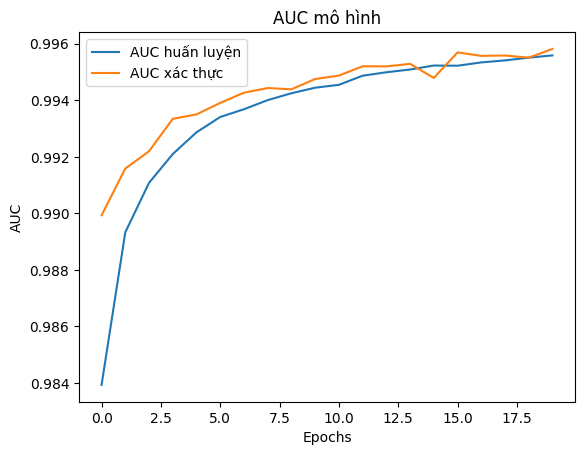

In [39]:
# 5. Vẽ AUC huấn luyện và xác thực
import matplotlib.pyplot as plt
if tf_available:
    plt.plot(history.history['auc'], label='AUC huấn luyện')
    plt.plot(history.history['val_auc'], label='AUC xác thực')
    plt.title('AUC mô hình')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()
    plt.show()
else:
    print("Bỏ qua vẽ AUC: TensorFlow không khả dụng.")

# **Giai đoạn 4: Xác thực chéo**

In [40]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [41]:
# 1. Khởi tạo các mô hình
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42, n_estimators=100)

In [42]:
# 2. Thực hiện xác thực chéo 5 lần
# Xác thực chéo cho Cây quyết định
dt_cv_scores = cross_val_score(decision_tree, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Điểm xác thực chéo Cây quyết định: {dt_cv_scores}")
print(f"Độ chính xác trung bình Cây quyết định: {dt_cv_scores.mean():.4f}")
print(f"Độ lệch chuẩn Cây quyết định: {dt_cv_scores.std():.4f}")

Điểm xác thực chéo Cây quyết định: [0.98685826 0.98776772 0.98635806 0.98508481 0.98667637]
Độ chính xác trung bình Cây quyết định: 0.9865
Độ lệch chuẩn Cây quyết định: 0.0009


In [43]:
# Xác thực chéo cho Rừng ngẫu nhiên
rf_cv_scores = cross_val_score(random_forest, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Điểm xác thực chéo Rừng ngẫu nhiên: {rf_cv_scores}")
print(f"Độ chính xác trung bình Rừng ngẫu nhiên: {rf_cv_scores.mean():.4f}")
print(f"Độ lệch chuẩn Rừng ngẫu nhiên: {rf_cv_scores.std():.4f}")

Điểm xác thực chéo Rừng ngẫu nhiên: [0.99108726 0.99104179 0.98995043 0.98981401 0.99013233]
Độ chính xác trung bình Rừng ngẫu nhiên: 0.9904
Độ lệch chuẩn Rừng ngẫu nhiên: 0.0005


In [44]:
# 3. So sánh các điểm trung bình
if rf_cv_scores.mean() > dt_cv_scores.mean():
    print("Rừng ngẫu nhiên tổng quát hóa tốt hơn trên tập dữ liệu này.")
else:
    print("Cây quyết định tổng quát hóa tốt hơn trên tập dữ liệu này.")

Rừng ngẫu nhiên tổng quát hóa tốt hơn trên tập dữ liệu này.


# **Giai đoạn 5: Đánh giá và so sánh mô hình**

In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [46]:
# 1. Huấn luyện các mô hình Cây quyết định và Rừng ngẫu nhiên trên toàn bộ tập huấn luyện
decision_tree.fit(X_train_scaled, y_train)
random_forest.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
# 2. Dự đoán trên tập kiểm tra
dt_predictions = decision_tree.predict(X_test_scaled)
rf_predictions = random_forest.predict(X_test_scaled)

In [48]:
# 3. Đánh giá Cây quyết định
print("Đánh giá Cây quyết định:")
dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_conf_matrix = confusion_matrix(y_test, dt_predictions)
dt_class_report = classification_report(y_test, dt_predictions)

print(f"Độ chính xác: {dt_accuracy:.4f}")
print(f"Ma trận nhầm lẫn:\n{dt_conf_matrix}")
print(f"Báo cáo phân loại:\n{dt_class_report}")

Đánh giá Cây quyết định:
Độ chính xác: 0.9879
Ma trận nhầm lẫn:
[[19120   185]
 [  147  8037]]
Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19305
           1       0.98      0.98      0.98      8184

    accuracy                           0.99     27489
   macro avg       0.98      0.99      0.99     27489
weighted avg       0.99      0.99      0.99     27489



In [49]:
# 4. Đánh giá Rừng ngẫu nhiên
print("\nĐánh giá Rừng ngẫu nhiên:")
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_conf_matrix = confusion_matrix(y_test, rf_predictions)
rf_class_report = classification_report(y_test, rf_predictions)

print(f"Độ chính xác: {rf_accuracy:.4f}")
print(f"Ma trận nhầm lẫn:\n{rf_conf_matrix}")
print(f"Báo cáo phân loại:\n{rf_class_report}")


Đánh giá Rừng ngẫu nhiên:
Độ chính xác: 0.9919
Ma trận nhầm lẫn:
[[19184   121]
 [  102  8082]]
Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19305
           1       0.99      0.99      0.99      8184

    accuracy                           0.99     27489
   macro avg       0.99      0.99      0.99     27489
weighted avg       0.99      0.99      0.99     27489



In [50]:
# 5. Đánh giá mô hình phân cụm KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

# Nếu biến `kmeans` chưa tồn tại (ví dụ: ô huấn luyện chưa được chạy) thì khởi tạo và huấn luyện lại
if 'kmeans' not in globals():
    print("Biến 'kmeans' chưa tồn tại — sẽ huấn luyện KMeans trên X_train_scaled bây giờ.")
    kmeans = KMeans(n_clusters=2, random_state=42)
    kmeans.fit(X_train_scaled)

kmeans_predictions = kmeans.predict(X_test_scaled)
kmeans_adjusted_rand = adjusted_rand_score(y_test, kmeans_predictions)

print("\nĐánh giá Phân cụm KMeans:")
print(f"Chỉ số Rand điều chỉnh (ARI): {kmeans_adjusted_rand:.4f}")


Đánh giá Phân cụm KMeans:
Chỉ số Rand điều chỉnh (ARI): 0.4811


# **So sánh:**

**Mô hình tốt nhất tổng thể:**

* Rừng ngẫu nhiên đạt độ chính xác tốt nhất tổng thể (99.19%) trong các mô hình.

**Tính nhất quán của kết quả: Xác thực chéo so với chia tách Tàu-Kiểm tra:**

Cả Cây quyết định và Rừng ngẫu nhiên đều thể hiện hiệu suất nhất quán giữa việc chia dữ liệu đơn giản và xác thực chéo 5 lần.

1. Cây quyết định:

* Độ chính xác chia đơn giản: 98.79% (0.9879)
* Độ chính xác trung bình xác thực chéo: 98.65% (0.9865)

2. Rừng ngẫu nhiên:

* Độ chính xác chia đơn giản: 99.19% (0.9919)
* Độ chính xác trung bình xác thực chéo: 99.04% (0.9904)

Kết quả nhất quán giữa chia dữ liệu đơn giản và xác thực chéo cho cả hai mô hình. Điều này xác nhận tính mạnh mẽ và hiệu suất đáng tin cậy của chúng trên tập dữ liệu.

**Hiệu quả của KMeans:**

* KMeans không phân biệt hiệu quả giữa malware và tệp hợp pháp so với các mô hình được giám sát. Điều này là do KMeans chỉ dựa vào phân phối đặc trưng, và dữ liệu có thể có các vùng chồng chéo được phân tách tốt hơn bằng học có giám sát.